In [5]:
import pandas as pd
from sklearn import metrics
import numpy as np
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

In [6]:
def f1_score_manual(y_true, y_pred):
    TP = sum((y_true[i] == 1 and y_pred[i] == 1) for i in range(len(y_true)))  # True Positives
    FP = sum((y_true[i] == 0 and y_pred[i] == 1) for i in range(len(y_true)))  # False Positives
    FN = sum((y_true[i] == 1 and y_pred[i] == 0) for i in range(len(y_true)))  # False Negatives
    TN = sum((y_true[i] == 0 and y_pred[i] == 0) for i in range(len(y_true)))  # True Negatives

    # Precision and Recall Calculation
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0

    # F1 Score Calculation
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return f1, TP, FP, FN, TN

In [7]:
dataset_name = "huge-0.1-2.csv"
dataset_type = "synthetic/var"
# dataset_type = "synthetic/mse"
model = "w2v"

In [8]:
result_columns = [
    "case_id", 
    "prefix_length", 
    "anomaly_score", 
    "threshold", 
    "y_pred",
    "y_true",
    "anomaly_type", 
    "encoding_duration", 
    "scoring_duration", 
    "prediction_duration"
]

# df_source = pd.read_csv(f"data/{dataset_type}/{dataset_name}")
df_results = pd.read_csv(f"results/{dataset_type}/results_{model}_{dataset_name}", header=None, names=result_columns)

In [9]:
def print_confusion_matrix(TP, TN, FP, FN):
    print("Confusion Matrix:")
    print(f"         Predicted Positive  Predicted Negative")
    print(f"Actual Positive    {TP}                  {FN}")
    print(f"Actual Negative    {FP}                  {TN}")

In [10]:
def sum_of_distances(n):
    total_sum = 0
    for j in range(1, n):  # Loop through each event except the last
        total_sum += (n - j) * (n - j + 1) // 2  # Use formula to sum distances
    return total_sum

In [11]:
def average_distance(n):
    n = int(round(n))
    total_sum = 0
    count = 0
    for j in range(1, n):  # Loop through each event except the last
        pairs = (n - j) * (n - j + 1) // 2  # Number of distance pairs
        total_sum += pairs  # Sum up all distances
        count += (n - j)  # Count total number of distances
    return total_sum / count if count > 0 else 0  # Calculate average

# batch_sizes = [1,2,4,8,16,32,64]
batch_sizes = [1,4,8,16,32,64]
average_synthetic_arrival_time = 28.85 / 60
# average_synthetic_case_length = 
# total_synthetic_events = 23672
average_realworld_arrival_time = 48.5 / 60
# average_realworld_case_length = 55.36658653846154
# total_realworld_events = 52214


for batch_size in batch_sizes:
    print(
        batch_size, '&',
        round(average_distance(batch_size),1), '&',
        batch_size, '&',
        round(average_distance(batch_size-1) * average_synthetic_arrival_time, 1),'&',
        round((batch_size-1) * average_synthetic_arrival_time, 1), '&',
        round(average_distance(batch_size-1) * average_realworld_arrival_time, 1),'&',
        round((batch_size-1) * average_realworld_arrival_time, 1), '\\\\',
    )


1 & 0 & 1 & 0.0 & 0.0 & 0.0 & 0.0 \\
4 & 1.7 & 4 & 0.6 & 1.4 & 1.1 & 2.4 \\
8 & 3.0 & 8 & 1.3 & 3.4 & 2.2 & 5.7 \\
16 & 5.7 & 16 & 2.6 & 7.2 & 4.3 & 12.1 \\
32 & 11.0 & 32 & 5.1 & 14.9 & 8.6 & 25.1 \\
64 & 21.7 & 64 & 10.3 & 30.3 & 17.2 & 50.9 \\


In [12]:
n = df_results.shape[0]
print(n)
print(sum_of_distances(n))
print(average_distance(n))
print(average_distance(8))
print(average_distance(32))

77007
76109586707056
25669.333333333332
3.0
11.0


In [13]:
df_results = df_results.sort_values(by=["case_id","prefix_length"])
# df_source = df_source.sort_values(by=["case_id", "event_position"])

In [14]:
df_filtered = df_results[['case_id', 'y_pred', 'y_true']]
df_grouped = df_filtered.groupby('case_id').agg(
    y_true=('y_true', lambda x: 1 if (x == 1).any() else 0),
    y_pred=('y_pred', lambda x: 1 if (x == 1).any() else 0)
).reset_index()

In [15]:
y_prob = df_results["anomaly_score"].to_numpy()
y_pred = df_results["y_pred"].to_numpy()
y_true = df_results["y_true"].to_numpy()
y_threshold = df_results["threshold"].to_numpy()

y_pred_grouped = df_grouped["y_pred"].to_numpy()
y_true_grouped = df_grouped["y_true"].to_numpy()

print(len(y_true), len(y_pred))
print(df_results["y_true"].unique())
print(df_results["y_pred"].unique())

77007 77007
[0 1]
[0 1]


In [16]:
y_threshold

array([0.01500798, 0.016927  , 0.02097017, ..., 0.01722226, 0.01946593,
       0.02037673])

In [17]:
print(np.isnan(y_threshold).sum())
y_threshold = y_threshold[~np.isnan(y_threshold)]
y_mean_threshold = np.mean(y_threshold)
print(y_mean_threshold)

8
0.03004670343441869


In [18]:
def print_confusion_matrix(TP, TN, FP, FN):
    print("Confusion Matrix:")
    print(f"         Predicted Positive  Predicted Negative")
    print(f"Actual Positive    {TP}                  {FN}")
    print(f"Actual Negative    {FP}                  {TN}")


In [19]:
# Compute class frequencies
class_counts = np.bincount(y_true)  # Count occurrences of each class
total_samples = len(y_true)

# Compute inverse class weights (rarer class gets a higher weight)
class_weights = class_counts / total_samples  # Direct frequency proportion
class_weights_inverted = total_samples / (len(class_counts) * class_counts)  

# Assign weights to each sample based on its class
sample_weights = np.array([class_weights[label] for label in y_true])
sample_weights_inverted = np.array([class_weights_inverted[label] for label in y_true])

In [20]:
# Paper - 2020 - Anomaly_Detection_on_Event_Logs_with_a_Scarcity_of_Labels
# https://github.com/gbrltv/ProcessAnomalyDetector/blob/master/process_anomaly.py#L88

f1_binary = metrics.f1_score(y_true, y_pred, average='binary') # Default is binary
f1_micro = metrics.f1_score(y_true, y_pred, average='micro')
f1_macro = metrics.f1_score(y_true, y_pred, average='macro')
f1_weighted = metrics.f1_score(y_true, y_pred, average='weighted')
f1_weighted_inverted = metrics.f1_score(y_true, y_pred, average='weighted', sample_weight=sample_weights_inverted)
f1_binary_beta_05 = metrics.fbeta_score(y_true, y_pred, beta=0.5, average='binary')
f1_binary_beta_2 = metrics.fbeta_score(y_true, y_pred, beta=2, average='binary')
accuracy = metrics.accuracy_score(y_true, y_pred)
# f1_samples = metrics.f1_score(y_true, y_pred, average='samples') # Not supported for binary classification

print(f"F1 Score (Binary): {f1_binary}")
print(f"F1 Score (Micro): {f1_micro}")
print(f"F1 Score (Macro): {f1_macro}")
print(f"F1 Score (Weighted): {f1_weighted}")
print(f"F1 Score (Weighted Inverted): {f1_weighted_inverted}")
print(f"Accuracy: {accuracy}")
print(f"F1 Score (Binary Beta): {f1_binary_beta_05}")
print(f"F1 Score (Binary Beta): {f1_binary_beta_2}")
# print(f"F1 Score (Samples): {f1_samples}")


F1 Score (Binary): 0.20511475409836066
F1 Score (Micro): 0.7638786084381939
F1 Score (Macro): 0.5332301746151218
F1 Score (Weighted): 0.8119197133549739
F1 Score (Weighted Inverted): 0.5830718438313629
Accuracy: 0.7638786084381939
F1 Score (Binary Beta): 0.15829959514170042
F1 Score (Binary Beta): 0.29124767225325887


In [21]:
f1_binary = metrics.f1_score(y_true_grouped, y_pred_grouped, average='binary')
print(f"F1 Score (Binary): {f1_binary}")

F1 Score (Binary): 0.24726927338926705


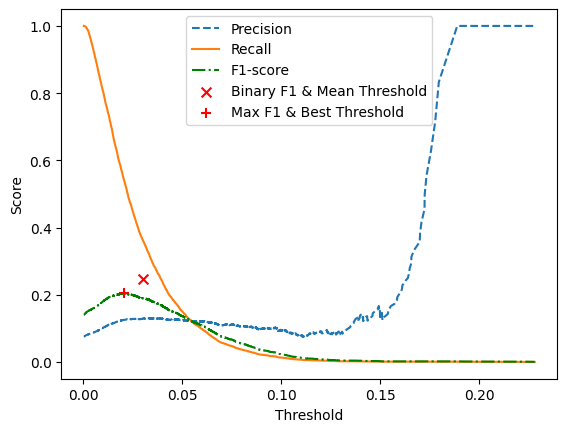

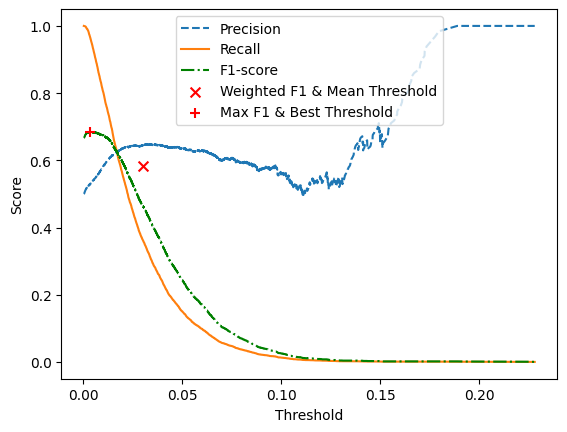

In [22]:
precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
weighted_precision, weighted_recall, weighted_thresholds = precision_recall_curve(y_true, y_prob, sample_weight=sample_weights)
weighted_precision_inverted, weighted_recall_inverted, weighted_thresholds_inverted = precision_recall_curve(y_true, y_prob, sample_weight=sample_weights_inverted)

def plot_precision_recall(precision, recall, thresholds, expected_y, expected_f1, f1_type, title="Precision-Recall Curve"):
    f1_scores = 2 * (precision * recall) / (precision + recall)
    f1_scores = np.nan_to_num(f1_scores)

    max_f1_index = np.argmax(f1_scores)
    max_f1_score = f1_scores[max_f1_index]
    best_threshold = thresholds[max_f1_index]
    
    # Plot Precision-Recall curve
    plt.plot(thresholds, precision[:-1], label="Precision", linestyle='--')
    plt.plot(thresholds, recall[:-1], label="Recall")
    plt.plot(thresholds, f1_scores[:-1], label="F1-score", linestyle='-.', color="green")
    plt.scatter(expected_y, expected_f1, color='red', marker='x', s=50, zorder=3, label=f"{f1_type} F1 & Mean Threshold")
    plt.scatter(best_threshold, max_f1_score, color='red', marker='+', s=50, zorder=3, label="Max F1 & Best Threshold")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.show()

plot_precision_recall(precision, recall, thresholds, y_mean_threshold, f1_binary, f1_type="Binary", title="Precision-Recall Curve")
plot_precision_recall(weighted_precision_inverted, weighted_recall_inverted, weighted_thresholds_inverted, y_mean_threshold, f1_weighted_inverted, f1_type="Weighted", title="Weighted Precision-Recall Curve")

In [23]:
f1, TP, FP, FN, TN = f1_score_manual(y_true, y_pred)
print("F1 Score:", f1)

print_confusion_matrix(TP, TN, FP, FN)

F1 Score: 0.20511475409836066
Confusion Matrix:
         Predicted Positive  Predicted Negative
Actual Positive    2346                  3454
Actual Negative    14729                  56478


In [24]:
df_results

,case_id,prefix_length,anomaly_score,threshold,y_pred,y_true,anomaly_type,encoding_duration,scoring_duration,prediction_duration
49808,1,0,0.008950,0.015008,0,0,Normal,0.002939,0.002503,0.014807
49818,1,1,0.013543,0.016927,0,0,Normal,0.002489,0.002379,0.013711
49829,1,2,0.018769,0.020970,0,0,Normal,0.003766,0.002077,0.014405
49840,1,3,0.037908,0.023221,1,0,Normal,0.002190,0.003000,0.014362
49669,1,4,0.006788,0.025206,0,0,Normal,0.002012,0.003000,0.013755
...,...,...,...,...,...,...,...,...,...,...
61157,10000,0,0.000312,0.012218,0,0,Normal,0.003077,0.001995,0.015980
61178,10000,1,0.002802,0.013846,0,0,Normal,0.003478,0.002514,0.015651
61200,10000,2,0.003298,0.017222,0,0,Normal,0.003565,0.003005,0.014960
61221,10000,3,0.005388,0.019466,0,0,Normal,0.002211,0.003093,0.013818
